# Spectral Variational Autoencoder for Hyperspectral Anomaly Detection

This notebook develops a variational autoencoder for unsupervised anomaly detection in AVIRIS hyperspectral imagery.

The model learns a probabilistic latent representation of each hyperspectral pixel. Anomaly scores are calculated using spectral reconstruction error and latent-space divergence.

Pixels that are difficult to reconstruct or do not fit the learned latent distribution receive higher anomaly scores.

In [14]:
%pip install numpy scipy pandas matplotlib scikit-learn torch joblib

Note: you may need to restart the kernel to use updated packages.


In [16]:
import os
import random
import time
import copy
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.io import loadmat

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    roc_curve,
    precision_recall_curve,
    classification_report,
    confusion_matrix
)

import torch

from torch import nn

from torch.utils.data import (
    TensorDataset,
    DataLoader,
    random_split
)

import joblib

warnings.filterwarnings("ignore")

print("Libraries imported successfully.")

Libraries imported successfully.


In [18]:
RANDOM_STATE = 42

random.seed(
    RANDOM_STATE
)

np.random.seed(
    RANDOM_STATE
)

torch.manual_seed(
    RANDOM_STATE
)

if torch.cuda.is_available():

    torch.cuda.manual_seed_all(
        RANDOM_STATE
    )

    torch.backends.cudnn.deterministic = True

    torch.backends.cudnn.benchmark = False

print(
    "Random seed set to:",
    RANDOM_STATE
)

Random seed set to: 42


In [20]:
device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

print(
    "Device being used:",
    device
)

Device being used: cpu


In [22]:
DATA_PATH = "/Users/monicachaganti/Desktop/hyperspectral-anomaly-detection/data/aviris_1.mat"

RESULTS_DIR = "../results"

MODELS_DIR = "../models"

os.makedirs(
    RESULTS_DIR,
    exist_ok=True
)

os.makedirs(
    MODELS_DIR,
    exist_ok=True
)

print(
    "Dataset path:",
    DATA_PATH
)

print(
    "Results directory:",
    RESULTS_DIR
)

print(
    "Models directory:",
    MODELS_DIR
)

Dataset path: /Users/monicachaganti/Desktop/hyperspectral-anomaly-detection/data/aviris_1.mat
Results directory: ../results
Models directory: ../models


In [24]:
if not os.path.exists(
    DATA_PATH
):

    raise FileNotFoundError(
        f"Dataset not found at {DATA_PATH}. "
        "Place aviris_1.mat inside the data folder."
    )

print(
    "Dataset found successfully."
)

Dataset found successfully.


In [26]:
mat_file = loadmat(
    DATA_PATH
)

print(
    "Variables inside the MAT file:"
)

for key, value in mat_file.items():

    if not key.startswith("__"):

        print(
            key,
            type(value),
            getattr(
                value,
                "shape",
                None
            )
        )

Variables inside the MAT file:
data <class 'numpy.ndarray'> (100, 100, 189)
map <class 'numpy.ndarray'> (100, 100)


In [28]:
cube = mat_file[
    "data"
].astype(
    np.float32
)

ground_truth = np.squeeze(
    mat_file["map"]
)

ground_truth = (
    ground_truth > 0
).astype(
    np.uint8
)

print(
    "Hyperspectral cube shape:",
    cube.shape
)

print(
    "Ground-truth shape:",
    ground_truth.shape
)

print(
    "Ground-truth values:",
    np.unique(
        ground_truth
    )
)

Hyperspectral cube shape: (100, 100, 189)
Ground-truth shape: (100, 100)
Ground-truth values: [0 1]


In [30]:
cube = np.nan_to_num(
    cube,
    nan=0.0,
    posinf=0.0,
    neginf=0.0
)

print(
    "NaN values:",
    np.isnan(cube).sum()
)

print(
    "Infinite values:",
    np.isinf(cube).sum()
)

NaN values: 0
Infinite values: 0


In [32]:
height, width, bands = cube.shape

total_pixels = (
    height
    * width
)

print(
    "Image height:",
    height
)

print(
    "Image width:",
    width
)

print(
    "Number of spectral bands:",
    bands
)

print(
    "Total number of pixels:",
    total_pixels
)

Image height: 100
Image width: 100
Number of spectral bands: 189
Total number of pixels: 10000


In [34]:
number_of_anomalies = int(
    ground_truth.sum()
)

number_of_background_pixels = (
    total_pixels
    - number_of_anomalies
)

anomaly_percentage = (
    number_of_anomalies
    / total_pixels
) * 100

print(
    "Background pixels:",
    number_of_background_pixels
)

print(
    "Anomaly pixels:",
    number_of_anomalies
)

print(
    f"Anomaly percentage: "
    f"{anomaly_percentage:.4f}%"
)

Background pixels: 9936
Anomaly pixels: 64
Anomaly percentage: 0.6400%


In [36]:
X = cube.reshape(
    -1,
    bands
)

y = ground_truth.reshape(
    -1
)

print(
    "Feature matrix shape:",
    X.shape
)

print(
    "Label vector shape:",
    y.shape
)

Feature matrix shape: (10000, 189)
Label vector shape: (10000,)


In [38]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(
    X
).astype(
    np.float32
)

print(
    "Scaled feature shape:",
    X_scaled.shape
)

print(
    "Scaled mean:",
    X_scaled.mean()
)

print(
    "Scaled standard deviation:",
    X_scaled.std()
)

Scaled feature shape: (10000, 189)
Scaled mean: 6.9754464e-09
Scaled standard deviation: 0.9999999


In [40]:
X_tensor = torch.tensor(
    X_scaled,
    dtype=torch.float32
)

dataset = TensorDataset(
    X_tensor
)

print(
    "Number of samples:",
    len(dataset)
)

print(
    "Shape of one sample:",
    dataset[0][0].shape
)

Number of samples: 10000
Shape of one sample: torch.Size([189])


In [42]:
training_size = int(
    0.85
    * len(dataset)
)

validation_size = (
    len(dataset)
    - training_size
)

training_dataset, validation_dataset = random_split(
    dataset,
    [
        training_size,
        validation_size
    ],
    generator=torch.Generator().manual_seed(
        RANDOM_STATE
    )
)

print(
    "Training samples:",
    len(training_dataset)
)

print(
    "Validation samples:",
    len(validation_dataset)
)

Training samples: 8500
Validation samples: 1500


In [44]:
BATCH_SIZE = 256

training_loader = DataLoader(
    training_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

validation_loader = DataLoader(
    validation_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print(
    "Training batches:",
    len(training_loader)
)

print(
    "Validation batches:",
    len(validation_loader)
)

Training batches: 34
Validation batches: 6


In [46]:
LATENT_DIMENSION = 16

BETA = 0.001

print(
    "Latent dimension:",
    LATENT_DIMENSION
)

print(
    "KL-divergence weight:",
    BETA
)

Latent dimension: 16
KL-divergence weight: 0.001


In [48]:
class SpectralVAE(
    nn.Module
):

    def __init__(
        self,
        number_of_bands,
        latent_dimension
    ):

        super().__init__()

        self.number_of_bands = (
            number_of_bands
        )

        self.latent_dimension = (
            latent_dimension
        )

        self.encoder = nn.Sequential(

            nn.Linear(
                number_of_bands,
                128
            ),

            nn.ReLU(),

            nn.BatchNorm1d(
                128
            ),

            nn.Linear(
                128,
                64
            ),

            nn.ReLU()
        )

        self.mean_layer = nn.Linear(
            64,
            latent_dimension
        )

        self.log_variance_layer = nn.Linear(
            64,
            latent_dimension
        )

        self.decoder = nn.Sequential(

            nn.Linear(
                latent_dimension,
                64
            ),

            nn.ReLU(),

            nn.Linear(
                64,
                128
            ),

            nn.ReLU(),

            nn.Linear(
                128,
                number_of_bands
            )
        )

    def encode(
        self,
        x
    ):

        encoded_features = self.encoder(
            x
        )

        latent_mean = self.mean_layer(
            encoded_features
        )

        latent_log_variance = self.log_variance_layer(
            encoded_features
        )

        return (
            latent_mean,
            latent_log_variance
        )

    def reparameterize(
        self,
        latent_mean,
        latent_log_variance
    ):

        latent_standard_deviation = torch.exp(
            0.5
            * latent_log_variance
        )

        random_noise = torch.randn_like(
            latent_standard_deviation
        )

        latent_sample = (
            latent_mean
            + random_noise
            * latent_standard_deviation
        )

        return latent_sample

    def decode(
        self,
        latent_sample
    ):

        reconstructed_spectrum = self.decoder(
            latent_sample
        )

        return reconstructed_spectrum

    def forward(
        self,
        x
    ):

        latent_mean, latent_log_variance = self.encode(
            x
        )

        latent_sample = self.reparameterize(
            latent_mean,
            latent_log_variance
        )

        reconstructed_spectrum = self.decode(
            latent_sample
        )

        return (
            reconstructed_spectrum,
            latent_mean,
            latent_log_variance
        )

In [50]:
model = SpectralVAE(
    number_of_bands=bands,
    latent_dimension=LATENT_DIMENSION
)

model = model.to(
    device
)

print(
    model
)

SpectralVAE(
  (encoder): Sequential(
    (0): Linear(in_features=189, out_features=128, bias=True)
    (1): ReLU()
    (2): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
  )
  (mean_layer): Linear(in_features=64, out_features=16, bias=True)
  (log_variance_layer): Linear(in_features=64, out_features=16, bias=True)
  (decoder): Sequential(
    (0): Linear(in_features=16, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=189, bias=True)
  )
)


In [52]:
example_batch = next(
    iter(
        training_loader
    )
)[0]

example_batch = example_batch.to(
    device
)

with torch.no_grad():

    (
        example_reconstruction,
        example_mean,
        example_log_variance
    ) = model(
        example_batch
    )

print(
    "Input shape:",
    example_batch.shape
)

print(
    "Reconstruction shape:",
    example_reconstruction.shape
)

print(
    "Latent mean shape:",
    example_mean.shape
)

print(
    "Latent log-variance shape:",
    example_log_variance.shape
)

Input shape: torch.Size([256, 189])
Reconstruction shape: torch.Size([256, 189])
Latent mean shape: torch.Size([256, 16])
Latent log-variance shape: torch.Size([256, 16])


In [54]:
number_of_parameters = sum(

    parameter.numel()

    for parameter in model.parameters()

    if parameter.requires_grad
)

print(
    "Number of trainable parameters:",
    number_of_parameters
)

Number of trainable parameters: 68701


In [56]:
def calculate_vae_loss(
    reconstructed_spectra,
    original_spectra,
    latent_mean,
    latent_log_variance,
    beta
):

    reconstruction_loss = torch.mean(
        (
            reconstructed_spectra
            - original_spectra
        ) ** 2
    )

    kl_divergence = -0.5 * torch.mean(
        1
        + latent_log_variance
        - latent_mean.pow(2)
        - latent_log_variance.exp()
    )

    total_loss = (
        reconstruction_loss
        + beta
        * kl_divergence
    )

    return (
        total_loss,
        reconstruction_loss,
        kl_divergence
    )

In [58]:
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001,
    weight_decay=0.00001
)

print(
    "Optimizer:",
    optimizer
)

Optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 1e-05
)


In [60]:
def train_spectral_vae(
    model,
    training_loader,
    validation_loader,
    optimizer,
    device,
    beta,
    maximum_epochs=100,
    patience=15
):

    training_loss_history = []

    validation_loss_history = []

    training_reconstruction_history = []

    validation_reconstruction_history = []

    training_kl_history = []

    validation_kl_history = []

    best_validation_loss = float(
        "inf"
    )

    best_model_state = None

    epochs_without_improvement = 0

    for epoch in range(
        1,
        maximum_epochs + 1
    ):

        model.train()

        total_training_loss = 0.0

        total_training_reconstruction = 0.0

        total_training_kl = 0.0

        for batch in training_loader:

            spectra = batch[0].to(
                device
            )

            optimizer.zero_grad()

            (
                reconstructed_spectra,
                latent_mean,
                latent_log_variance
            ) = model(
                spectra
            )

            (
                loss,
                reconstruction_loss,
                kl_divergence
            ) = calculate_vae_loss(
                reconstructed_spectra,
                spectra,
                latent_mean,
                latent_log_variance,
                beta
            )

            loss.backward()

            optimizer.step()

            batch_size = spectra.size(
                0
            )

            total_training_loss += (
                loss.item()
                * batch_size
            )

            total_training_reconstruction += (
                reconstruction_loss.item()
                * batch_size
            )

            total_training_kl += (
                kl_divergence.item()
                * batch_size
            )

        average_training_loss = (
            total_training_loss
            / len(
                training_loader.dataset
            )
        )

        average_training_reconstruction = (
            total_training_reconstruction
            / len(
                training_loader.dataset
            )
        )

        average_training_kl = (
            total_training_kl
            / len(
                training_loader.dataset
            )
        )

        model.eval()

        total_validation_loss = 0.0

        total_validation_reconstruction = 0.0

        total_validation_kl = 0.0

        with torch.no_grad():

            for batch in validation_loader:

                spectra = batch[0].to(
                    device
                )

                (
                    reconstructed_spectra,
                    latent_mean,
                    latent_log_variance
                ) = model(
                    spectra
                )

                (
                    validation_loss,
                    validation_reconstruction,
                    validation_kl
                ) = calculate_vae_loss(
                    reconstructed_spectra,
                    spectra,
                    latent_mean,
                    latent_log_variance,
                    beta
                )

                batch_size = spectra.size(
                    0
                )

                total_validation_loss += (
                    validation_loss.item()
                    * batch_size
                )

                total_validation_reconstruction += (
                    validation_reconstruction.item()
                    * batch_size
                )

                total_validation_kl += (
                    validation_kl.item()
                    * batch_size
                )

        average_validation_loss = (
            total_validation_loss
            / len(
                validation_loader.dataset
            )
        )

        average_validation_reconstruction = (
            total_validation_reconstruction
            / len(
                validation_loader.dataset
            )
        )

        average_validation_kl = (
            total_validation_kl
            / len(
                validation_loader.dataset
            )
        )

        training_loss_history.append(
            average_training_loss
        )

        validation_loss_history.append(
            average_validation_loss
        )

        training_reconstruction_history.append(
            average_training_reconstruction
        )

        validation_reconstruction_history.append(
            average_validation_reconstruction
        )

        training_kl_history.append(
            average_training_kl
        )

        validation_kl_history.append(
            average_validation_kl
        )

        if (
            average_validation_loss
            < best_validation_loss
        ):

            best_validation_loss = (
                average_validation_loss
            )

            best_model_state = copy.deepcopy(
                model.state_dict()
            )

            epochs_without_improvement = 0

        else:

            epochs_without_improvement += 1

        if (
            epoch == 1
            or epoch % 10 == 0
        ):

            print(
                f"Epoch {epoch:03d} | "
                f"Training Loss: "
                f"{average_training_loss:.6f} | "
                f"Validation Loss: "
                f"{average_validation_loss:.6f} | "
                f"Validation Reconstruction: "
                f"{average_validation_reconstruction:.6f} | "
                f"Validation KL: "
                f"{average_validation_kl:.6f}"
            )

        if (
            epochs_without_improvement
            >= patience
        ):

            print(
                "Early stopping activated."
            )

            break

    model.load_state_dict(
        best_model_state
    )

    history = {

        "training_loss":
        training_loss_history,

        "validation_loss":
        validation_loss_history,

        "training_reconstruction":
        training_reconstruction_history,

        "validation_reconstruction":
        validation_reconstruction_history,

        "training_kl":
        training_kl_history,

        "validation_kl":
        validation_kl_history
    }

    return history

In [62]:
start_time = time.time()

training_history = train_spectral_vae(
    model=model,
    training_loader=training_loader,
    validation_loader=validation_loader,
    optimizer=optimizer,
    device=device,
    beta=BETA,
    maximum_epochs=100,
    patience=15
)

training_time = (
    time.time()
    - start_time
)

print(
    f"Training completed in "
    f"{training_time:.2f} seconds."
)

Epoch 001 | Training Loss: 0.467154 | Validation Loss: 0.080488 | Validation Reconstruction: 0.078011 | Validation KL: 2.477326
Epoch 010 | Training Loss: 0.024064 | Validation Loss: 0.017187 | Validation Reconstruction: 0.014376 | Validation KL: 2.810957
Epoch 020 | Training Loss: 0.016202 | Validation Loss: 0.008853 | Validation Reconstruction: 0.006220 | Validation KL: 2.632529
Epoch 030 | Training Loss: 0.012598 | Validation Loss: 0.009300 | Validation Reconstruction: 0.006804 | Validation KL: 2.496234
Epoch 040 | Training Loss: 0.011479 | Validation Loss: 0.009889 | Validation Reconstruction: 0.007627 | Validation KL: 2.261809
Epoch 050 | Training Loss: 0.011503 | Validation Loss: 0.006686 | Validation Reconstruction: 0.004554 | Validation KL: 2.132172
Epoch 060 | Training Loss: 0.009650 | Validation Loss: 0.006933 | Validation Reconstruction: 0.004822 | Validation KL: 2.110736
Epoch 070 | Training Loss: 0.009647 | Validation Loss: 0.008154 | Validation Reconstruction: 0.006144 | 

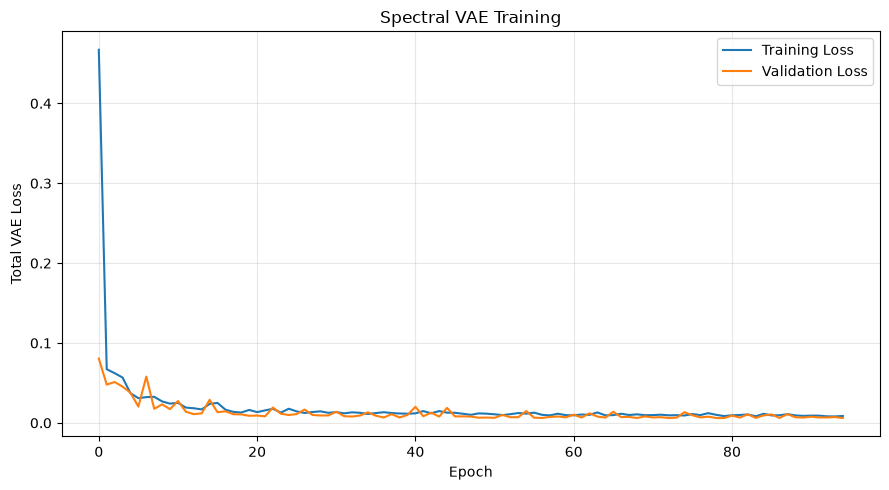

In [64]:
plt.figure(
    figsize=(9, 5)
)

plt.plot(
    training_history[
        "training_loss"
    ],
    label="Training Loss"
)

plt.plot(
    training_history[
        "validation_loss"
    ],
    label="Validation Loss"
)

plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "Total VAE Loss"
)

plt.title(
    "Spectral VAE Training"
)

plt.legend()

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.show()

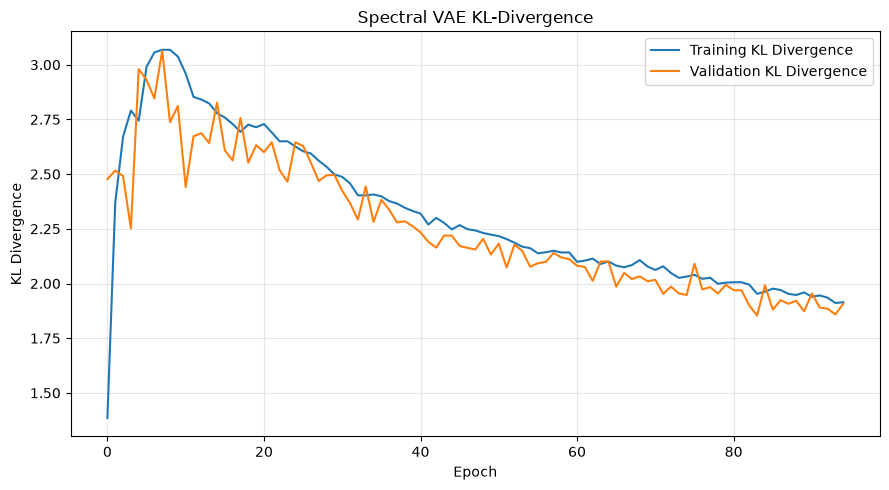

In [68]:
plt.figure(
    figsize=(9, 5)
)

plt.plot(
    training_history[
        "training_kl"
    ],
    label="Training KL Divergence"
)

plt.plot(
    training_history[
        "validation_kl"
    ],
    label="Validation KL Divergence"
)

plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "KL Divergence"
)

plt.title(
    "Spectral VAE KL-Divergence"
)

plt.legend()

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.show()

In [70]:
all_spectra_tensor = torch.tensor(
    X_scaled,
    dtype=torch.float32
).to(
    device
)

print(
    "All spectra tensor shape:",
    all_spectra_tensor.shape
)

All spectra tensor shape: torch.Size([10000, 189])


In [72]:
model.eval()

with torch.no_grad():

    (
        latent_mean,
        latent_log_variance
    ) = model.encode(
        all_spectra_tensor
    )

    reconstructed_spectra_tensor = model.decode(
        latent_mean
    )

reconstructed_spectra = (
    reconstructed_spectra_tensor
    .cpu()
    .numpy()
)

latent_mean_array = (
    latent_mean
    .cpu()
    .numpy()
)

latent_log_variance_array = (
    latent_log_variance
    .cpu()
    .numpy()
)

print(
    "Reconstructed spectra shape:",
    reconstructed_spectra.shape
)

print(
    "Latent mean shape:",
    latent_mean_array.shape
)

print(
    "Latent log-variance shape:",
    latent_log_variance_array.shape
)

Reconstructed spectra shape: (10000, 189)
Latent mean shape: (10000, 16)
Latent log-variance shape: (10000, 16)


In [74]:
reconstruction_errors = np.mean(
    (
        X_scaled
        - reconstructed_spectra
    ) ** 2,
    axis=1
)

print(
    "Minimum reconstruction error:",
    reconstruction_errors.min()
)

print(
    "Maximum reconstruction error:",
    reconstruction_errors.max()
)

print(
    "Mean reconstruction error:",
    reconstruction_errors.mean()
)

Minimum reconstruction error: 0.0005742521
Maximum reconstruction error: 0.10905761
Mean reconstruction error: 0.0035927745


In [76]:
kl_divergence_scores = -0.5 * np.mean(
    1
    + latent_log_variance_array
    - latent_mean_array ** 2
    - np.exp(
        latent_log_variance_array
    ),
    axis=1
)

print(
    "Minimum KL score:",
    kl_divergence_scores.min()
)

print(
    "Maximum KL score:",
    kl_divergence_scores.max()
)

print(
    "Mean KL score:",
    kl_divergence_scores.mean()
)

Minimum KL score: 1.3554325
Maximum KL score: 17.89827
Mean KL score: 2.0277987


In [78]:
combined_anomaly_scores = (
    reconstruction_errors
    + BETA
    * kl_divergence_scores
)

print(
    "Minimum combined anomaly score:",
    combined_anomaly_scores.min()
)

print(
    "Maximum combined anomaly score:",
    combined_anomaly_scores.max()
)

print(
    "Mean combined anomaly score:",
    combined_anomaly_scores.mean()
)

Minimum combined anomaly score: 0.0020989391
Maximum combined anomaly score: 0.111674815
Mean combined anomaly score: 0.005620573


In [80]:
vae_reconstruction_map = reconstruction_errors.reshape(
    height,
    width
)

vae_kl_map = kl_divergence_scores.reshape(
    height,
    width
)

vae_anomaly_map = combined_anomaly_scores.reshape(
    height,
    width
)

print(
    "Reconstruction map shape:",
    vae_reconstruction_map.shape
)

print(
    "KL map shape:",
    vae_kl_map.shape
)

print(
    "Combined anomaly map shape:",
    vae_anomaly_map.shape
)

Reconstruction map shape: (100, 100)
KL map shape: (100, 100)
Combined anomaly map shape: (100, 100)


In [82]:
normalized_reconstruction_map = (
    vae_reconstruction_map
    - vae_reconstruction_map.min()
) / (
    vae_reconstruction_map.max()
    - vae_reconstruction_map.min()
    + 1e-8
)

normalized_kl_map = (
    vae_kl_map
    - vae_kl_map.min()
) / (
    vae_kl_map.max()
    - vae_kl_map.min()
    + 1e-8
)

normalized_anomaly_map = (
    vae_anomaly_map
    - vae_anomaly_map.min()
) / (
    vae_anomaly_map.max()
    - vae_anomaly_map.min()
    + 1e-8
)

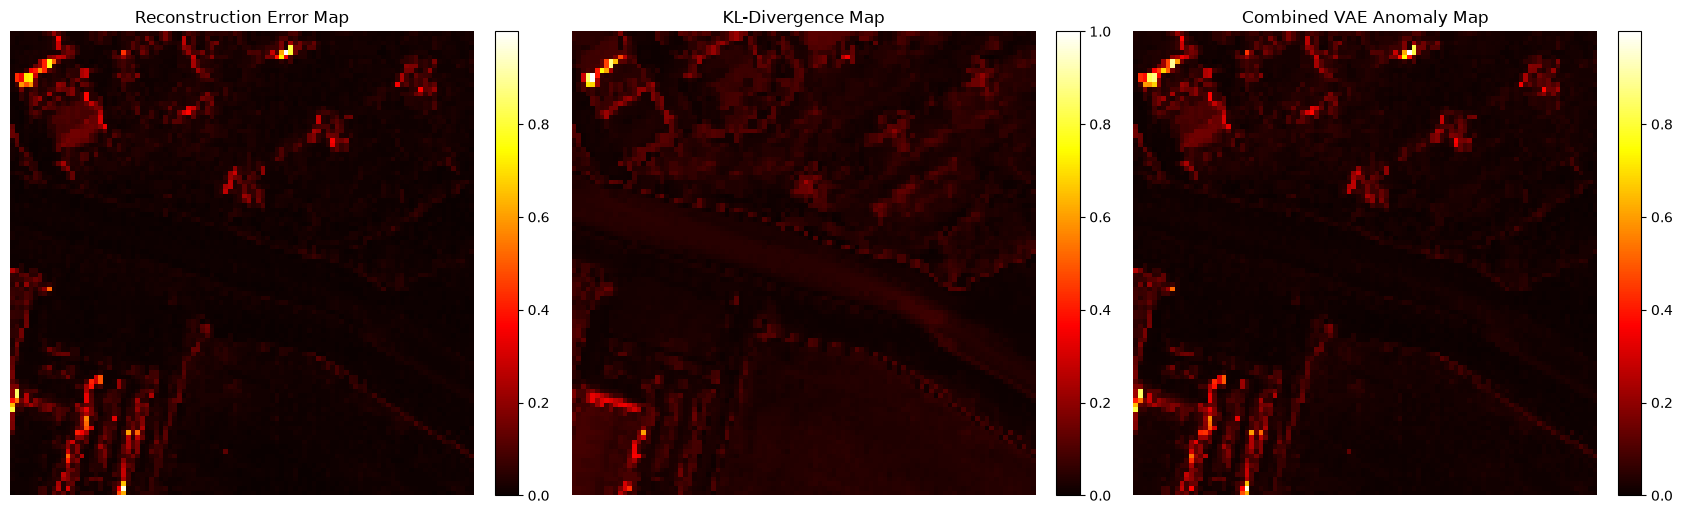

In [84]:
figure, axes = plt.subplots(
    1,
    3,
    figsize=(17, 5)
)

image_1 = axes[0].imshow(
    normalized_reconstruction_map,
    cmap="hot"
)

axes[0].set_title(
    "Reconstruction Error Map"
)

axes[0].axis(
    "off"
)

figure.colorbar(
    image_1,
    ax=axes[0],
    fraction=0.046,
    pad=0.04
)

image_2 = axes[1].imshow(
    normalized_kl_map,
    cmap="hot"
)

axes[1].set_title(
    "KL-Divergence Map"
)

axes[1].axis(
    "off"
)

figure.colorbar(
    image_2,
    ax=axes[1],
    fraction=0.046,
    pad=0.04
)

image_3 = axes[2].imshow(
    normalized_anomaly_map,
    cmap="hot"
)

axes[2].set_title(
    "Combined VAE Anomaly Map"
)

axes[2].axis(
    "off"
)

figure.colorbar(
    image_3,
    ax=axes[2],
    fraction=0.046,
    pad=0.04
)

plt.tight_layout()

plt.show()

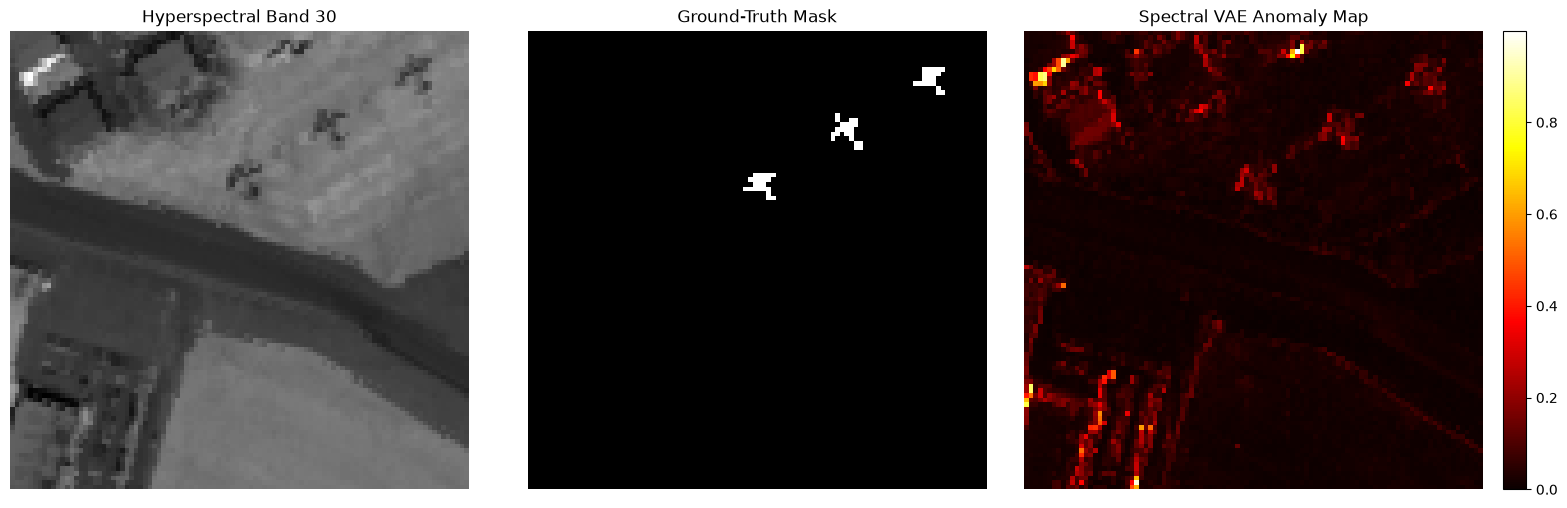

In [86]:
figure, axes = plt.subplots(
    1,
    3,
    figsize=(16, 5)
)

axes[0].imshow(
    cube[
        :,
        :,
        30
    ],
    cmap="gray"
)

axes[0].set_title(
    "Hyperspectral Band 30"
)

axes[0].axis(
    "off"
)

axes[1].imshow(
    ground_truth,
    cmap="gray"
)

axes[1].set_title(
    "Ground-Truth Mask"
)

axes[1].axis(
    "off"
)

image = axes[2].imshow(
    normalized_anomaly_map,
    cmap="hot"
)

axes[2].set_title(
    "Spectral VAE Anomaly Map"
)

axes[2].axis(
    "off"
)

figure.colorbar(
    image,
    ax=axes[2],
    fraction=0.046,
    pad=0.04
)

plt.tight_layout()

plt.show()

In [88]:
reconstruction_roc_auc = roc_auc_score(
    y,
    reconstruction_errors
)

reconstruction_pr_auc = average_precision_score(
    y,
    reconstruction_errors
)

print(
    f"Reconstruction-only ROC-AUC: "
    f"{reconstruction_roc_auc:.4f}"
)

print(
    f"Reconstruction-only PR-AUC: "
    f"{reconstruction_pr_auc:.4f}"
)

Reconstruction-only ROC-AUC: 0.9109
Reconstruction-only PR-AUC: 0.0356


In [90]:
kl_roc_auc = roc_auc_score(
    y,
    kl_divergence_scores
)

kl_pr_auc = average_precision_score(
    y,
    kl_divergence_scores
)

print(
    f"KL-only ROC-AUC: "
    f"{kl_roc_auc:.4f}"
)

print(
    f"KL-only PR-AUC: "
    f"{kl_pr_auc:.4f}"
)

KL-only ROC-AUC: 0.9688
KL-only PR-AUC: 0.1084


In [92]:
roc_auc = roc_auc_score(
    y,
    combined_anomaly_scores
)

pr_auc = average_precision_score(
    y,
    combined_anomaly_scores
)

print(
    f"Combined ROC-AUC: "
    f"{roc_auc:.4f}"
)

print(
    f"Combined PR-AUC: "
    f"{pr_auc:.4f}"
)

Combined ROC-AUC: 0.9259
Combined PR-AUC: 0.0412


In [94]:
score_comparison = pd.DataFrame(
    {
        "Score_Method": [
            "Reconstruction Error",
            "KL Divergence",
            "Combined VAE Score"
        ],

        "ROC_AUC": [
            reconstruction_roc_auc,
            kl_roc_auc,
            roc_auc
        ],

        "PR_AUC": [
            reconstruction_pr_auc,
            kl_pr_auc,
            pr_auc
        ]
    }
)

score_comparison.round(
    4
)

,Score_Method,ROC_AUC,PR_AUC
0,Reconstruction Error,0.9109,0.0356
1,KL Divergence,0.9688,0.1084
2,Combined VAE Score,0.9259,0.0412


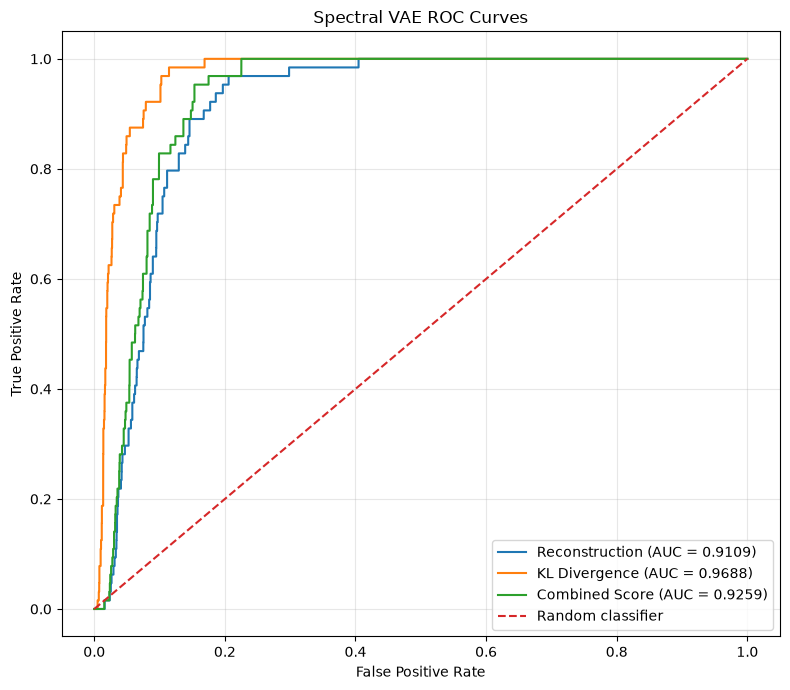

In [96]:
reconstruction_fpr, reconstruction_tpr, _ = roc_curve(
    y,
    reconstruction_errors
)

kl_fpr, kl_tpr, _ = roc_curve(
    y,
    kl_divergence_scores
)

combined_fpr, combined_tpr, _ = roc_curve(
    y,
    combined_anomaly_scores
)

plt.figure(
    figsize=(8, 7)
)

plt.plot(
    reconstruction_fpr,
    reconstruction_tpr,
    label=(
        f"Reconstruction "
        f"(AUC = {reconstruction_roc_auc:.4f})"
    )
)

plt.plot(
    kl_fpr,
    kl_tpr,
    label=(
        f"KL Divergence "
        f"(AUC = {kl_roc_auc:.4f})"
    )
)

plt.plot(
    combined_fpr,
    combined_tpr,
    label=(
        f"Combined Score "
        f"(AUC = {roc_auc:.4f})"
    )
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random classifier"
)

plt.xlabel(
    "False Positive Rate"
)

plt.ylabel(
    "True Positive Rate"
)

plt.title(
    "Spectral VAE ROC Curves"
)

plt.legend()

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.show()

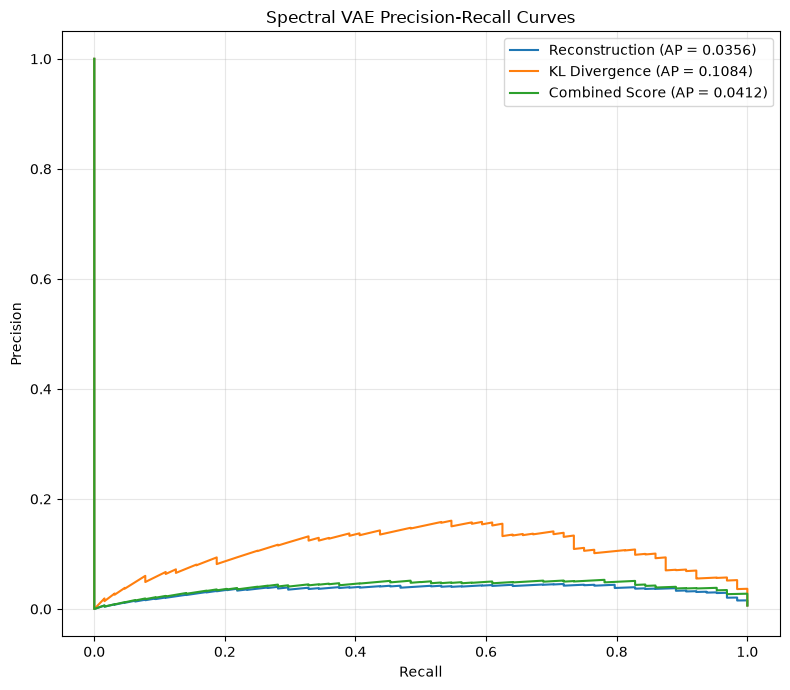

In [98]:
reconstruction_precision, reconstruction_recall, _ = (
    precision_recall_curve(
        y,
        reconstruction_errors
    )
)

kl_precision, kl_recall, _ = precision_recall_curve(
    y,
    kl_divergence_scores
)

combined_precision, combined_recall, _ = (
    precision_recall_curve(
        y,
        combined_anomaly_scores
    )
)

plt.figure(
    figsize=(8, 7)
)

plt.plot(
    reconstruction_recall,
    reconstruction_precision,
    label=(
        f"Reconstruction "
        f"(AP = {reconstruction_pr_auc:.4f})"
    )
)

plt.plot(
    kl_recall,
    kl_precision,
    label=(
        f"KL Divergence "
        f"(AP = {kl_pr_auc:.4f})"
    )
)

plt.plot(
    combined_recall,
    combined_precision,
    label=(
        f"Combined Score "
        f"(AP = {pr_auc:.4f})"
    )
)

plt.xlabel(
    "Recall"
)

plt.ylabel(
    "Precision"
)

plt.title(
    "Spectral VAE Precision-Recall Curves"
)

plt.legend()

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.show()

In [100]:
THRESHOLD_PERCENTILE = 99

threshold = np.percentile(
    combined_anomaly_scores,
    THRESHOLD_PERCENTILE
)

predicted_labels = (
    combined_anomaly_scores
    >= threshold
).astype(
    np.uint8
)

predicted_mask = predicted_labels.reshape(
    height,
    width
)

print(
    "Threshold:",
    threshold
)

print(
    "Predicted anomaly pixels:",
    predicted_labels.sum()
)

Threshold: 0.03113257884979248
Predicted anomaly pixels: 101


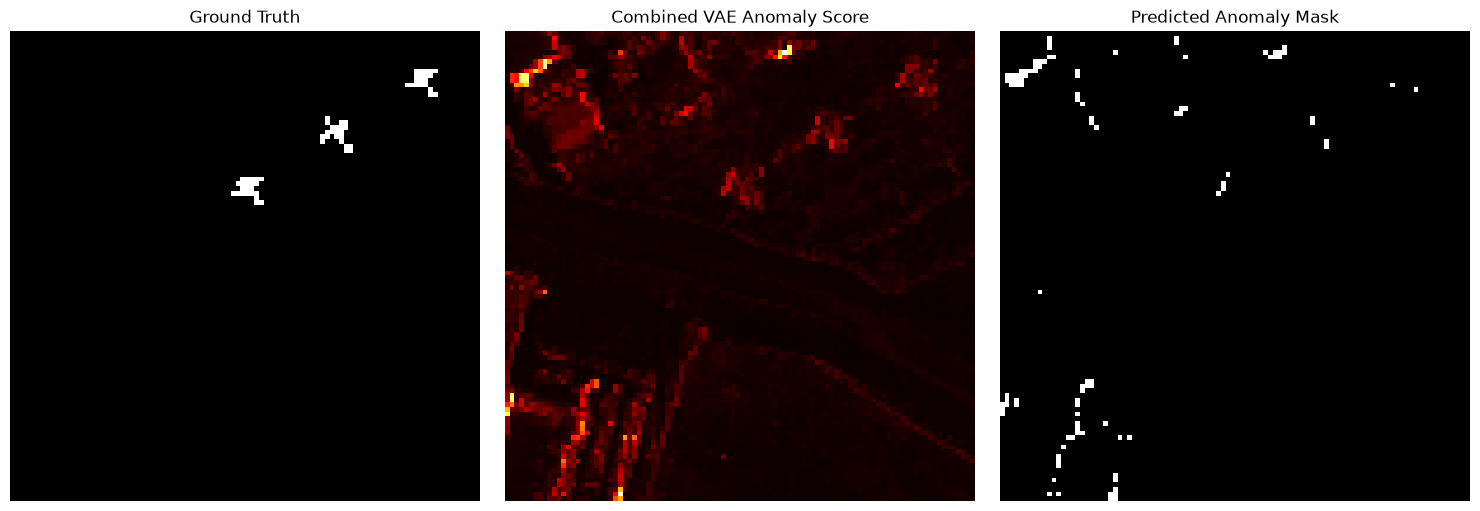

In [102]:
figure, axes = plt.subplots(
    1,
    3,
    figsize=(15, 5)
)

axes[0].imshow(
    ground_truth,
    cmap="gray"
)

axes[0].set_title(
    "Ground Truth"
)

axes[0].axis(
    "off"
)

axes[1].imshow(
    normalized_anomaly_map,
    cmap="hot"
)

axes[1].set_title(
    "Combined VAE Anomaly Score"
)

axes[1].axis(
    "off"
)

axes[2].imshow(
    predicted_mask,
    cmap="gray"
)

axes[2].set_title(
    "Predicted Anomaly Mask"
)

axes[2].axis(
    "off"
)

plt.tight_layout()

plt.show()

In [104]:
print(
    classification_report(
        y,
        predicted_labels,
        target_names=[
            "Background",
            "Anomaly"
        ],
        digits=4,
        zero_division=0
    )
)

              precision    recall  f1-score   support

  Background     0.9935    0.9898    0.9917      9936
     Anomaly     0.0000    0.0000    0.0000        64

    accuracy                         0.9835     10000
   macro avg     0.4968    0.4949    0.4958     10000
weighted avg     0.9872    0.9835    0.9853     10000



In [106]:
confusion_matrix_values = confusion_matrix(
    y,
    predicted_labels
)

confusion_matrix_table = pd.DataFrame(
    confusion_matrix_values,
    index=[
        "Actual Background",
        "Actual Anomaly"
    ],
    columns=[
        "Predicted Background",
        "Predicted Anomaly"
    ]
)

confusion_matrix_table

,Predicted Background,Predicted Anomaly
Actual Background,9835,101
Actual Anomaly,64,0


In [108]:
true_negative, false_positive, false_negative, true_positive = (
    confusion_matrix_values.ravel()
)

precision_score_value = (
    true_positive
    / (
        true_positive
        + false_positive
        + 1e-8
    )
)

recall_score_value = (
    true_positive
    / (
        true_positive
        + false_negative
        + 1e-8
    )
)

f1_score_value = (
    2
    * precision_score_value
    * recall_score_value
    / (
        precision_score_value
        + recall_score_value
        + 1e-8
    )
)

specificity = (
    true_negative
    / (
        true_negative
        + false_positive
        + 1e-8
    )
)

false_positive_rate_value = (
    false_positive
    / (
        false_positive
        + true_negative
        + 1e-8
    )
)

print(
    "True positives:",
    true_positive
)

print(
    "False positives:",
    false_positive
)

print(
    "False negatives:",
    false_negative
)

print(
    "True negatives:",
    true_negative
)

print(
    f"Precision: "
    f"{precision_score_value:.4f}"
)

print(
    f"Recall: "
    f"{recall_score_value:.4f}"
)

print(
    f"F1-score: "
    f"{f1_score_value:.4f}"
)

print(
    f"Specificity: "
    f"{specificity:.4f}"
)

print(
    f"False-positive rate: "
    f"{false_positive_rate_value:.6f}"
)

True positives: 0
False positives: 101
False negatives: 64
True negatives: 9835
Precision: 0.0000
Recall: 0.0000
F1-score: 0.0000
Specificity: 0.9898
False-positive rate: 0.010165


In [110]:
background_scores = combined_anomaly_scores[
    y == 0
]

anomaly_scores = combined_anomaly_scores[
    y == 1
]

print(
    "Mean background anomaly score:",
    background_scores.mean()
)

print(
    "Mean anomaly score:",
    anomaly_scores.mean()
)

print(
    "Median background anomaly score:",
    np.median(
        background_scores
    )
)

print(
    "Median anomaly score:",
    np.median(
        anomaly_scores
    )
)

Mean background anomaly score: 0.0055747256
Mean anomaly score: 0.012738505
Median background anomaly score: 0.00392679
Median anomaly score: 0.012180273


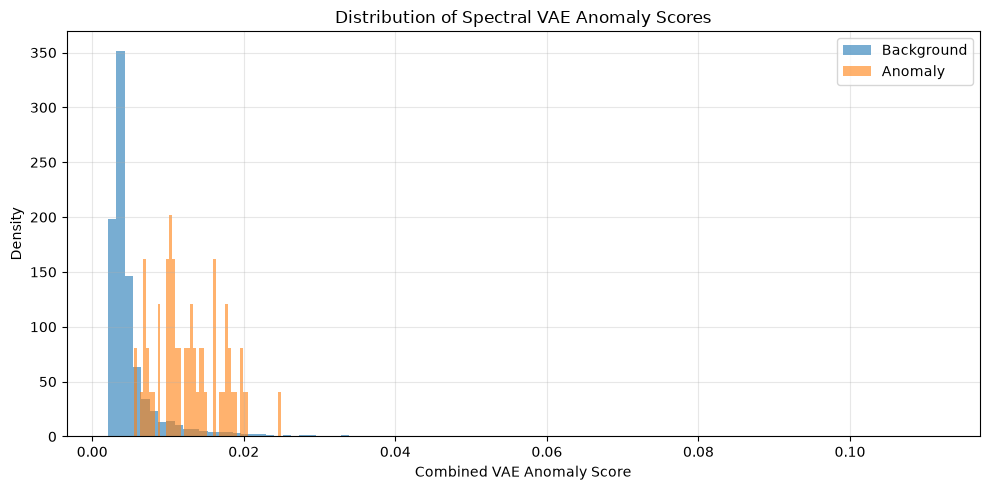

In [112]:
plt.figure(
    figsize=(10, 5)
)

plt.hist(
    background_scores,
    bins=100,
    alpha=0.6,
    density=True,
    label="Background"
)

plt.hist(
    anomaly_scores,
    bins=50,
    alpha=0.6,
    density=True,
    label="Anomaly"
)

plt.xlabel(
    "Combined VAE Anomaly Score"
)

plt.ylabel(
    "Density"
)

plt.title(
    "Distribution of Spectral VAE Anomaly Scores"
)

plt.legend()

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.show()

In [114]:
normal_pixel_index = np.where(
    y == 0
)[0][0]

anomaly_pixel_index = np.where(
    y == 1
)[0][0]

print(
    "Normal pixel index:",
    normal_pixel_index
)

print(
    "Anomaly pixel index:",
    anomaly_pixel_index
)

Normal pixel index: 0
Anomaly pixel index: 886


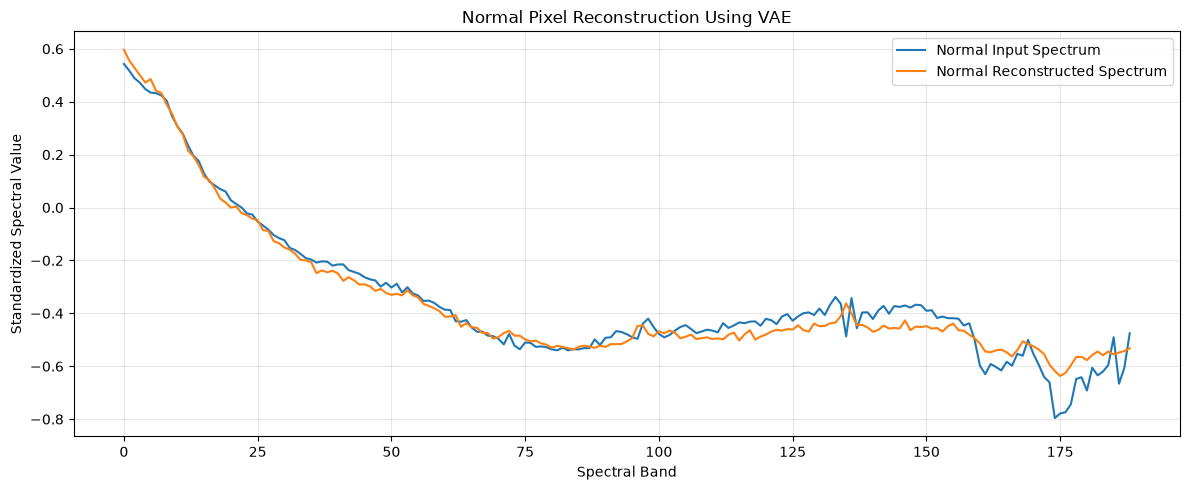

In [116]:
plt.figure(
    figsize=(12, 5)
)

plt.plot(
    X_scaled[
        normal_pixel_index
    ],
    label="Normal Input Spectrum"
)

plt.plot(
    reconstructed_spectra[
        normal_pixel_index
    ],
    label="Normal Reconstructed Spectrum"
)

plt.xlabel(
    "Spectral Band"
)

plt.ylabel(
    "Standardized Spectral Value"
)

plt.title(
    "Normal Pixel Reconstruction Using VAE"
)

plt.legend()

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.show()

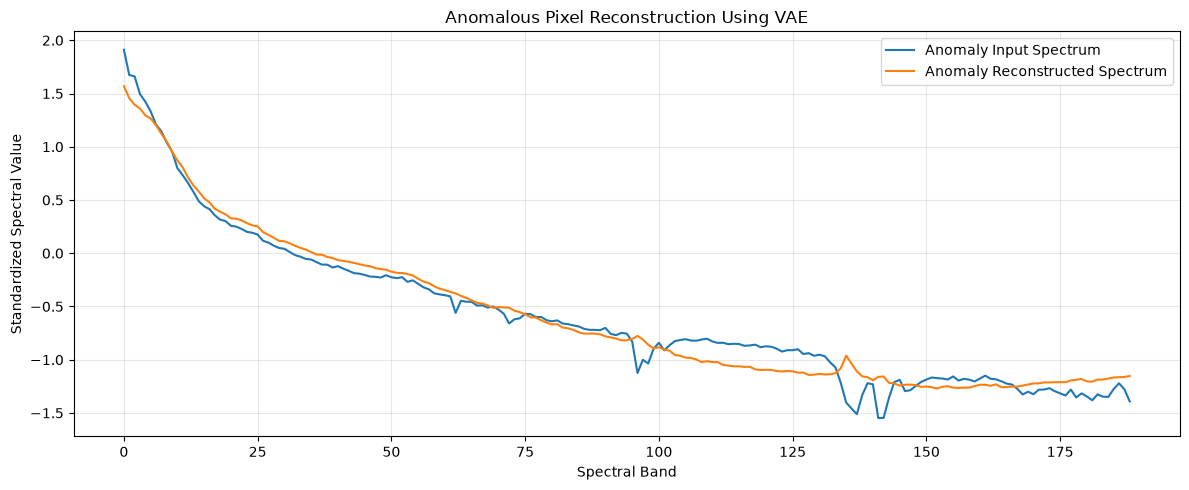

In [118]:
plt.figure(
    figsize=(12, 5)
)

plt.plot(
    X_scaled[
        anomaly_pixel_index
    ],
    label="Anomaly Input Spectrum"
)

plt.plot(
    reconstructed_spectra[
        anomaly_pixel_index
    ],
    label="Anomaly Reconstructed Spectrum"
)

plt.xlabel(
    "Spectral Band"
)

plt.ylabel(
    "Standardized Spectral Value"
)

plt.title(
    "Anomalous Pixel Reconstruction Using VAE"
)

plt.legend()

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.show()

In [120]:
latent_pca = PCA(
    n_components=2,
    random_state=RANDOM_STATE
)

two_dimensional_latent_features = latent_pca.fit_transform(
    latent_mean_array
)

print(
    "Latent PCA explained variance:",
    latent_pca.explained_variance_ratio_
)

Latent PCA explained variance: [0.59915984 0.19222386]


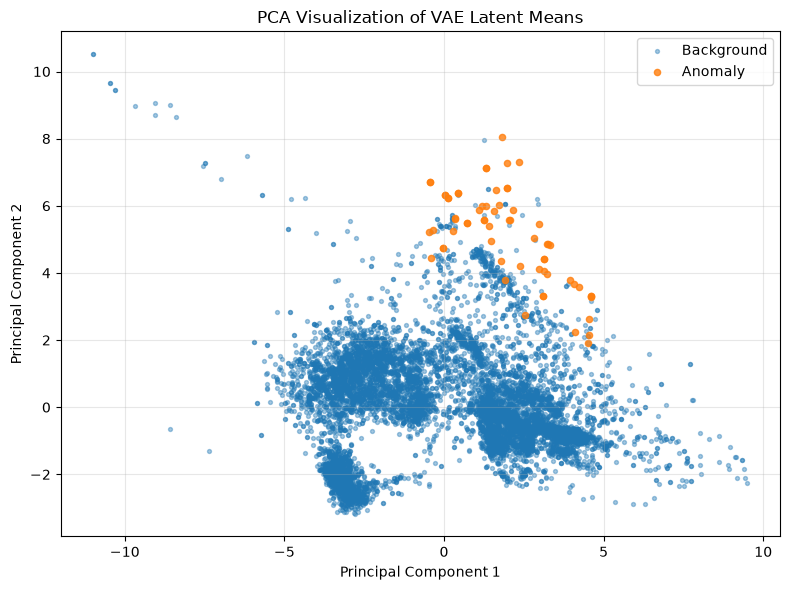

In [122]:
plt.figure(
    figsize=(8, 6)
)

plt.scatter(
    two_dimensional_latent_features[
        y == 0,
        0
    ],
    two_dimensional_latent_features[
        y == 0,
        1
    ],
    s=8,
    alpha=0.4,
    label="Background"
)

plt.scatter(
    two_dimensional_latent_features[
        y == 1,
        0
    ],
    two_dimensional_latent_features[
        y == 1,
        1
    ],
    s=20,
    alpha=0.8,
    label="Anomaly"
)

plt.xlabel(
    "Principal Component 1"
)

plt.ylabel(
    "Principal Component 2"
)

plt.title(
    "PCA Visualization of VAE Latent Means"
)

plt.legend()

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.show()

In [124]:
MODEL_PATH = os.path.join(
    MODELS_DIR,
    "spectral_vae.pt"
)

torch.save(
    {
        "model_state_dict":
        model.state_dict(),

        "number_of_bands":
        bands,

        "latent_dimension":
        LATENT_DIMENSION,

        "beta":
        BETA,

        "random_state":
        RANDOM_STATE,

        "training_history":
        training_history
    },
    MODEL_PATH
)

print(
    "Model saved to:",
    MODEL_PATH
)

Model saved to: ../models/spectral_vae.pt


In [126]:
SCALER_PATH = os.path.join(
    MODELS_DIR,
    "spectral_vae_scaler.joblib"
)

joblib.dump(
    scaler,
    SCALER_PATH
)

print(
    "Scaler saved to:",
    SCALER_PATH
)

Scaler saved to: ../models/spectral_vae_scaler.joblib


In [128]:
COMBINED_SCORE_PATH = os.path.join(
    RESULTS_DIR,
    "spectral_vae_scores.npy"
)

RECONSTRUCTION_SCORE_PATH = os.path.join(
    RESULTS_DIR,
    "spectral_vae_reconstruction_scores.npy"
)

KL_SCORE_PATH = os.path.join(
    RESULTS_DIR,
    "spectral_vae_kl_scores.npy"
)

np.save(
    COMBINED_SCORE_PATH,
    vae_anomaly_map
)

np.save(
    RECONSTRUCTION_SCORE_PATH,
    vae_reconstruction_map
)

np.save(
    KL_SCORE_PATH,
    vae_kl_map
)

print(
    "Combined anomaly scores saved to:",
    COMBINED_SCORE_PATH
)

print(
    "Reconstruction scores saved to:",
    RECONSTRUCTION_SCORE_PATH
)

print(
    "KL scores saved to:",
    KL_SCORE_PATH
)

Combined anomaly scores saved to: ../results/spectral_vae_scores.npy
Reconstruction scores saved to: ../results/spectral_vae_reconstruction_scores.npy
KL scores saved to: ../results/spectral_vae_kl_scores.npy


In [130]:
LATENT_MEAN_PATH = os.path.join(
    RESULTS_DIR,
    "spectral_vae_latent_means.npy"
)

LATENT_LOG_VARIANCE_PATH = os.path.join(
    RESULTS_DIR,
    "spectral_vae_latent_log_variances.npy"
)

np.save(
    LATENT_MEAN_PATH,
    latent_mean_array
)

np.save(
    LATENT_LOG_VARIANCE_PATH,
    latent_log_variance_array
)

print(
    "Latent means saved to:",
    LATENT_MEAN_PATH
)

print(
    "Latent log variances saved to:",
    LATENT_LOG_VARIANCE_PATH
)

Latent means saved to: ../results/spectral_vae_latent_means.npy
Latent log variances saved to: ../results/spectral_vae_latent_log_variances.npy


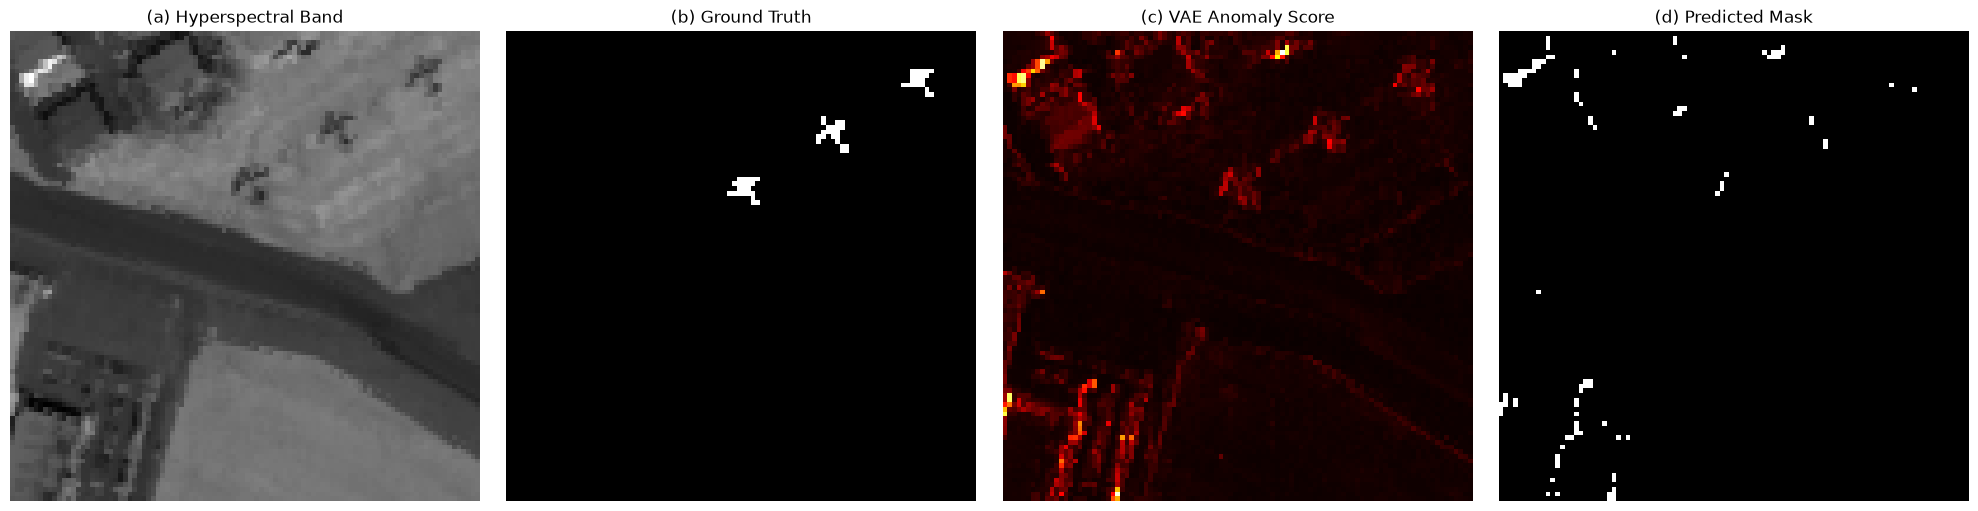

Figure saved to: ../results/spectral_vae_results.png


In [132]:
figure, axes = plt.subplots(
    1,
    4,
    figsize=(20, 5)
)

axes[0].imshow(
    cube[
        :,
        :,
        30
    ],
    cmap="gray"
)

axes[0].set_title(
    "(a) Hyperspectral Band"
)

axes[1].imshow(
    ground_truth,
    cmap="gray"
)

axes[1].set_title(
    "(b) Ground Truth"
)

axes[2].imshow(
    normalized_anomaly_map,
    cmap="hot"
)

axes[2].set_title(
    "(c) VAE Anomaly Score"
)

axes[3].imshow(
    predicted_mask,
    cmap="gray"
)

axes[3].set_title(
    "(d) Predicted Mask"
)

for axis in axes:

    axis.axis(
        "off"
    )

plt.tight_layout()

FIGURE_PATH = os.path.join(
    RESULTS_DIR,
    "spectral_vae_results.png"
)

plt.savefig(
    FIGURE_PATH,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    "Figure saved to:",
    FIGURE_PATH
)

In [134]:
results_table = pd.DataFrame(
    {
        "Dataset": [
            "AVIRIS-1 San Diego"
        ],

        "Model": [
            "Spectral Variational Autoencoder"
        ],

        "Latent_Dimension": [
            LATENT_DIMENSION
        ],

        "Beta": [
            BETA
        ],

        "ROC_AUC": [
            roc_auc
        ],

        "PR_AUC": [
            pr_auc
        ],

        "Reconstruction_ROC_AUC": [
            reconstruction_roc_auc
        ],

        "Reconstruction_PR_AUC": [
            reconstruction_pr_auc
        ],

        "KL_ROC_AUC": [
            kl_roc_auc
        ],

        "KL_PR_AUC": [
            kl_pr_auc
        ],

        "Threshold_Percentile": [
            THRESHOLD_PERCENTILE
        ],

        "Precision": [
            precision_score_value
        ],

        "Recall": [
            recall_score_value
        ],

        "F1": [
            f1_score_value
        ],

        "Specificity": [
            specificity
        ],

        "False_Positive_Rate": [
            false_positive_rate_value
        ],

        "Training_Time_Seconds": [
            training_time
        ],

        "Trainable_Parameters": [
            number_of_parameters
        ]
    }
)

results_table

,Dataset,Model,Latent_Dimension,Beta,ROC_AUC,PR_AUC,Reconstruction_ROC_AUC,Reconstruction_PR_AUC,KL_ROC_AUC,KL_PR_AUC,Threshold_Percentile,Precision,Recall,F1,Specificity,False_Positive_Rate,Training_Time_Seconds,Trainable_Parameters
0,AVIRIS-1 San Diego,Spectral Variational Autoencoder,16,0.001,0.925916,0.041194,0.910862,0.035589,0.968787,0.108386,99,0.0,0.0,0.0,0.989835,0.010165,13.343458,68701


In [136]:
METRICS_PATH = os.path.join(
    RESULTS_DIR,
    "spectral_vae_metrics.csv"
)

results_table.to_csv(
    METRICS_PATH,
    index=False
)

print(
    "Metrics saved to:",
    METRICS_PATH
)

Metrics saved to: ../results/spectral_vae_metrics.csv


In [138]:
DENSE_METRICS_PATH = os.path.join(
    RESULTS_DIR,
    "spectral_dense_autoencoder_metrics.csv"
)

CONV1D_METRICS_PATH = os.path.join(
    RESULTS_DIR,
    "conv1d_autoencoder_metrics.csv"
)

PATCH3D_METRICS_PATH = os.path.join(
    RESULTS_DIR,
    "patch3d_autoencoder_metrics.csv"
)

comparison_tables = []

if os.path.exists(
    DENSE_METRICS_PATH
):

    comparison_tables.append(
        pd.read_csv(
            DENSE_METRICS_PATH
        )
    )

if os.path.exists(
    CONV1D_METRICS_PATH
):

    comparison_tables.append(
        pd.read_csv(
            CONV1D_METRICS_PATH
        )
    )

if os.path.exists(
    PATCH3D_METRICS_PATH
):

    comparison_tables.append(
        pd.read_csv(
            PATCH3D_METRICS_PATH
        )
    )

comparison_tables.append(
    results_table
)

model_comparison = pd.concat(
    comparison_tables,
    ignore_index=True
)

display_columns = [
    "Model",
    "ROC_AUC",
    "PR_AUC",
    "Precision",
    "Recall",
    "F1",
    "Training_Time_Seconds",
    "Trainable_Parameters"
]

available_display_columns = [
    column
    for column in display_columns
    if column in model_comparison.columns
]

display(
    model_comparison[
        available_display_columns
    ].round(
        4
    )
)

,Model,ROC_AUC,PR_AUC,Precision,Recall,F1,Training_Time_Seconds,Trainable_Parameters
0,Spectral Dense Autoencoder,0.9106,0.0346,0.00,0.0000,0.0000,5.3244,69725
1,1D CNN Autoencoder,0.8944,0.0350,0.00,0.0000,0.0000,160.9251,17793
2,3D Patch Autoencoder,0.9038,0.0423,0.01,0.0156,0.0122,283.2971,35073
3,Spectral Variational Autoencoder,0.9259,0.0412,0.00,0.0000,0.0000,13.3435,68701


In [140]:
COMPARISON_PATH = os.path.join(
    RESULTS_DIR,
    "autoencoder_and_vae_comparison.csv"
)

model_comparison.to_csv(
    COMPARISON_PATH,
    index=False
)

print(
    "Combined comparison saved to:",
    COMPARISON_PATH
)

Combined comparison saved to: ../results/autoencoder_and_vae_comparison.csv


In [142]:
best_model_index = model_comparison[
    "ROC_AUC"
].astype(
    float
).idxmax()

best_model_row = model_comparison.loc[
    best_model_index
]

print(
    "Best model by ROC-AUC:",
    best_model_row[
        "Model"
    ]
)

print(
    f"Best ROC-AUC: "
    f"{float(best_model_row['ROC_AUC']):.4f}"
)

print(
    f"Corresponding PR-AUC: "
    f"{float(best_model_row['PR_AUC']):.4f}"
)

Best model by ROC-AUC: Spectral Variational Autoencoder
Best ROC-AUC: 0.9259
Corresponding PR-AUC: 0.0412


In [144]:
print(
    "=" * 75
)

print(
    "SPECTRAL VARIATIONAL AUTOENCODER "
    "EXPERIMENT SUMMARY"
)

print(
    "=" * 75
)

print(
    "Dataset: AVIRIS-1 San Diego"
)

print(
    "Cube shape:",
    cube.shape
)

print(
    "Model: Spectral Variational Autoencoder"
)

print(
    "Latent dimension:",
    LATENT_DIMENSION
)

print(
    "Beta:",
    BETA
)

print(
    "Trainable parameters:",
    number_of_parameters
)

print(
    f"Training time: "
    f"{training_time:.2f} seconds"
)

print(
    f"Reconstruction ROC-AUC: "
    f"{reconstruction_roc_auc:.4f}"
)

print(
    f"KL ROC-AUC: "
    f"{kl_roc_auc:.4f}"
)

print(
    f"Combined ROC-AUC: "
    f"{roc_auc:.4f}"
)

print(
    f"Combined PR-AUC: "
    f"{pr_auc:.4f}"
)

print(
    f"Precision: "
    f"{precision_score_value:.4f}"
)

print(
    f"Recall: "
    f"{recall_score_value:.4f}"
)

print(
    f"F1-score: "
    f"{f1_score_value:.4f}"
)

print(
    f"Specificity: "
    f"{specificity:.4f}"
)

print(
    "Saved model:",
    MODEL_PATH
)

print(
    "Saved anomaly map:",
    COMBINED_SCORE_PATH
)

print(
    "Saved latent means:",
    LATENT_MEAN_PATH
)

print(
    "=" * 75
)

SPECTRAL VARIATIONAL AUTOENCODER EXPERIMENT SUMMARY
Dataset: AVIRIS-1 San Diego
Cube shape: (100, 100, 189)
Model: Spectral Variational Autoencoder
Latent dimension: 16
Beta: 0.001
Trainable parameters: 68701
Training time: 13.34 seconds
Reconstruction ROC-AUC: 0.9109
KL ROC-AUC: 0.9688
Combined ROC-AUC: 0.9259
Combined PR-AUC: 0.0412
Precision: 0.0000
Recall: 0.0000
F1-score: 0.0000
Specificity: 0.9898
Saved model: ../models/spectral_vae.pt
Saved anomaly map: ../results/spectral_vae_scores.npy
Saved latent means: ../results/spectral_vae_latent_means.npy
